# Customer Churn Prediction System

## Data Science Internship – Phase 1

### 1. Project Overview

This project uses machine learning to predict whether a customer is
likely to leave a service or continue using it.

Customer churn prediction can help businesses identify customers who
are at higher risk of leaving and take appropriate retention measures.

### 2. Problem Statement

Customer churn can result in significant revenue loss for businesses.
The objective of this project is to analyze customer demographic,
subscription, service usage, and billing information and build a
machine learning classification model that predicts whether a
customer will churn.

### 3. Objectives

- Analyze customer churn data
- Clean and preprocess the dataset
- Explore factors associated with customer churn
- Analyze the relationship between tenure, monthly charges, and churn
- Perform feature engineering
- Encode categorical variables
- Build classification models
- Compare different machine learning algorithms
- Evaluate model performance
- Predict whether a customer is likely to churn

### 4. Dataset

The project uses a telecommunications customer churn dataset
containing customer demographic information, service details,
contract information, tenure, and billing information.

### 5. Target Variable

The target variable is:

**Churn**

Where:

- **Yes** = Customer has churned
- **No** = Customer has continued the service

In [3]:
# Import libraries required for data analysis, visualization, preprocessing, and machine learning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import warnings
warnings.filterwarnings("ignore")
print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
# Load the customer churn dataset from the data folder

df = pd.read_csv(
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
# Check the dataset structure, columns, data types, and non-null values
df.info()

# Display all column names available in the customer churn dataset
print("Total Columns:", len(df.columns))
print("\nColumn Names:")
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:

# Display the number of customers and features in the dataset
print("Number of Customers:", df.shape[0])
print("Number of Columns:", df.shape[1])

# Check the number of missing values in each column

missing_values = df.isnull().sum()
print("Missing Values:")
print(missing_values[missing_values > 0])

Number of Customers: 7043
Number of Columns: 21
Missing Values:
Series([], dtype: int64)


In [13]:
# Check whether the dataset contains duplicate records
duplicate_count = df.duplicated().sum()
print("Number of Duplicate Records:", duplicate_count)

# Generate descriptive statistics for numerical columns
df.describe()

Number of Duplicate Records: 0


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [17]:
# Display the number of unique values in each column
unique_values = df.nunique().sort_values()
print("Unique Values per Column:")
print(unique_values)

Unique Values per Column:
Churn                  2
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PaperlessBilling       2
PhoneService           2
Contract               3
StreamingMovies        3
StreamingTV            3
TechSupport            3
OnlineBackup           3
OnlineSecurity         3
InternetService        3
MultipleLines          3
DeviceProtection       3
PaymentMethod          4
tenure                73
MonthlyCharges      1585
TotalCharges        6531
customerID          7043
dtype: int64


In [19]:

# Analyze the distribution of the target variable, Churn
print("Churn Value Counts:")
print(df["Churn"].value_counts())
print("\nChurn Percentages:")
print(
    (df["Churn"].value_counts(normalize=True) * 100).round(2)
)

Churn Value Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentages:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [21]:
# Inspect the TotalCharges column before converting it to numeric format
print("TotalCharges Data Type:", df["TotalCharges"].dtype)
print("\nSample TotalCharges values:")
print(df["TotalCharges"].head(20))

# Convert TotalCharges from text to numeric values
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
print("TotalCharges Data Type After Conversion:", df["TotalCharges"].dtype)
print("Missing TotalCharges Values:", df["TotalCharges"].isnull().sum())

TotalCharges Data Type: object

Sample TotalCharges values:
0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: object
TotalCharges Data Type After Conversion: float64
Missing TotalCharges Values: 11


In [23]:
# Handle missing TotalCharges values using the median
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)
print("Missing values after handling TotalCharges:")
print(df["TotalCharges"].isnull().sum())

Missing values after handling TotalCharges:
0


In [25]:
# Remove Customer ID because it is an identifier and not a predictive feature
df_clean = df.drop("customerID", axis=1)
print("Dataset shape after removing Customer ID:", df_clean.shape)

Dataset shape after removing Customer ID: (7043, 20)


In [27]:

# Verify that the cleaned dataset contains no missing values or duplicate records
print("Total Missing Values:", df_clean.isnull().sum().sum())
print("Total Duplicate Records:", df_clean.duplicated().sum())
print("\nCleaned Dataset Shape:", df_clean.shape)

Total Missing Values: 0
Total Duplicate Records: 22

Cleaned Dataset Shape: (7043, 20)


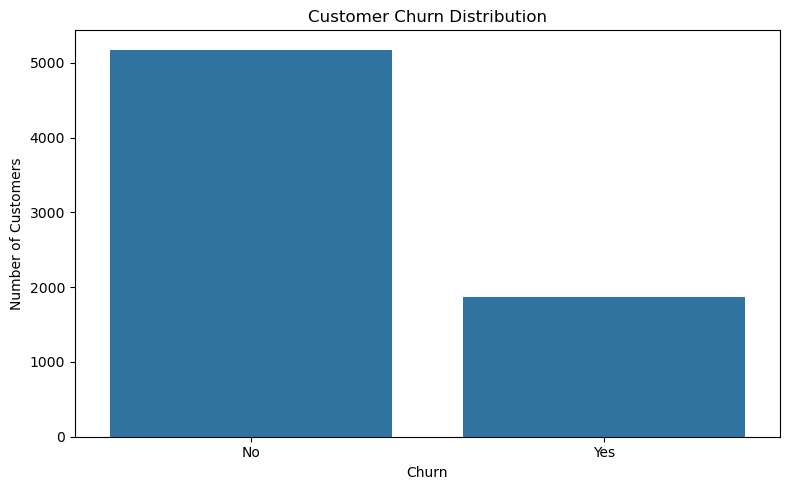

In [29]:
# Visualize the distribution of customers who churned and stayed
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_clean,
    x="Churn"
)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

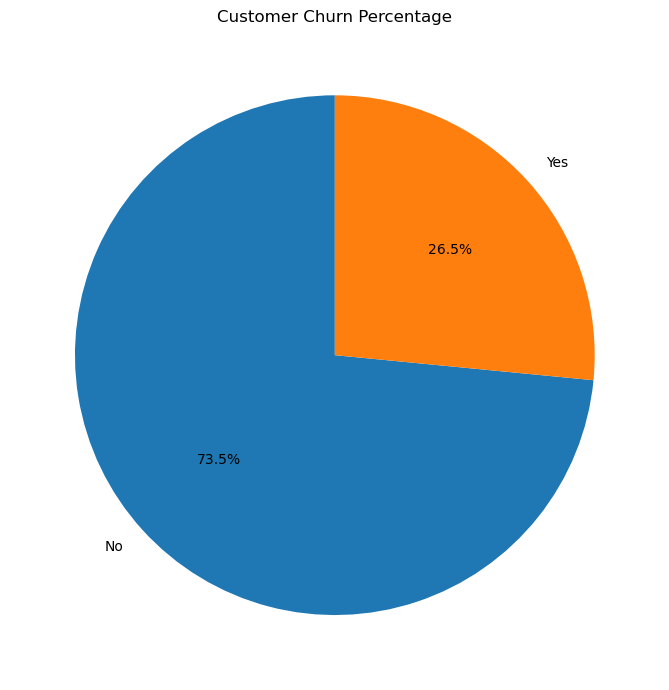

In [31]:
# Visualize the percentage of customers who churned versus stayed
churn_counts = df_clean["Churn"].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Customer Churn Percentage")
plt.tight_layout()
plt.show()

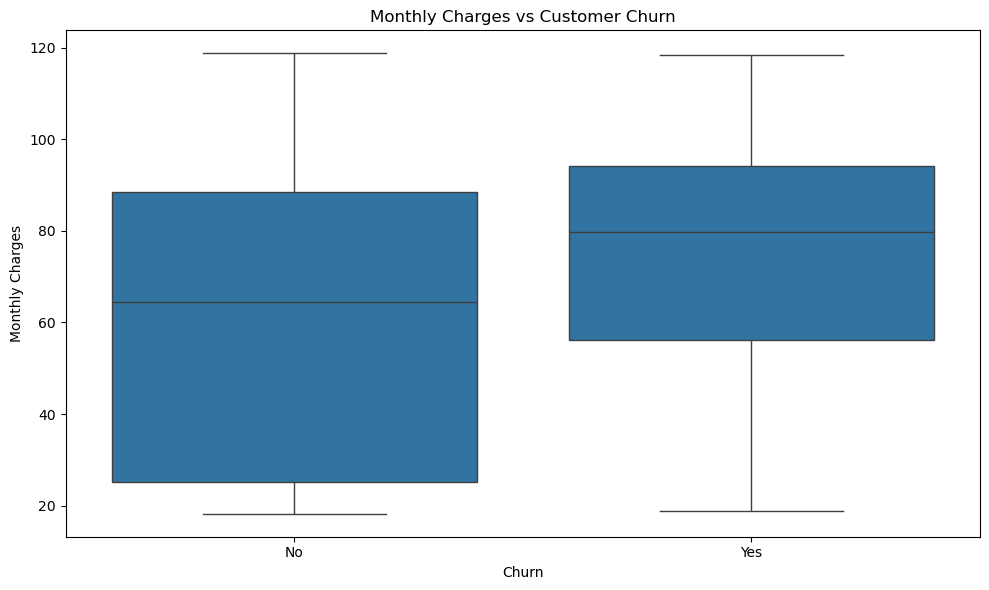

In [33]:
# Analyze the relationship between monthly charges and customer churn
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_clean,
    x="Churn",
    y="MonthlyCharges"
)
plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

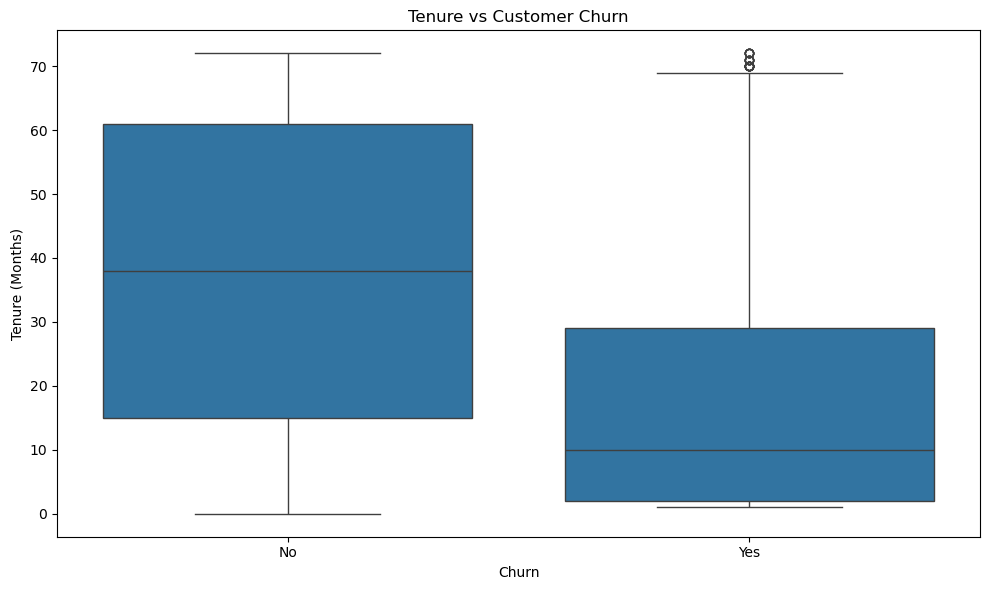

In [35]:
# Analyze the relationship between customer tenure and churn
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_clean,
    x="Churn",
    y="tenure"
)
plt.title("Tenure vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.tight_layout()
plt.show()

Churn Percentage by Contract Type:
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


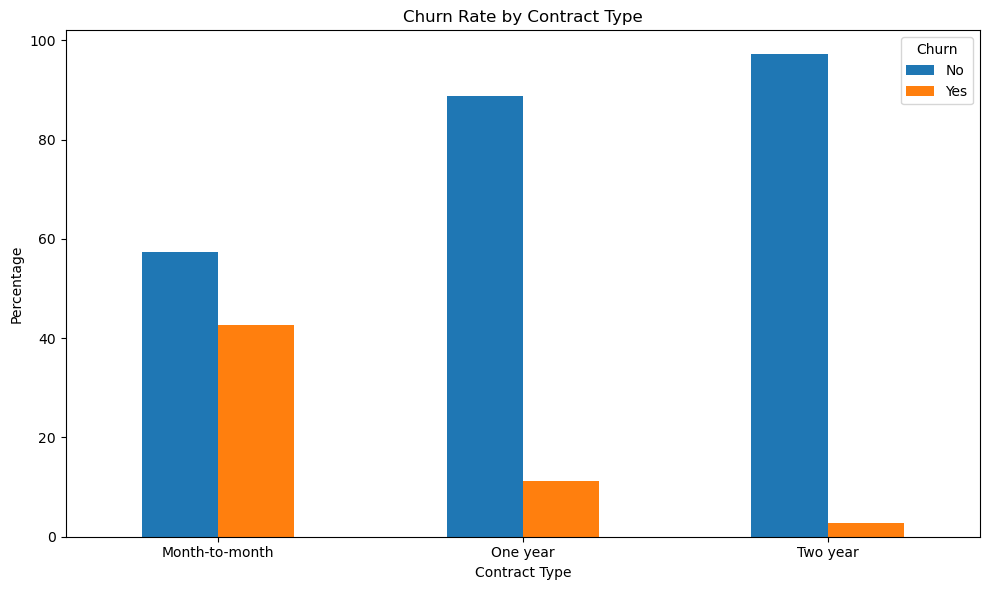

In [37]:
# Analyze churn rates across different contract types
contract_churn = pd.crosstab(
    df_clean["Contract"],
    df_clean["Churn"],
    normalize="index"
) * 100
print("Churn Percentage by Contract Type:")
print(contract_churn.round(2))
contract_churn.plot(
    kind="bar",
    figsize=(10, 6)
)
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

Churn Percentage by Internet Service:
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


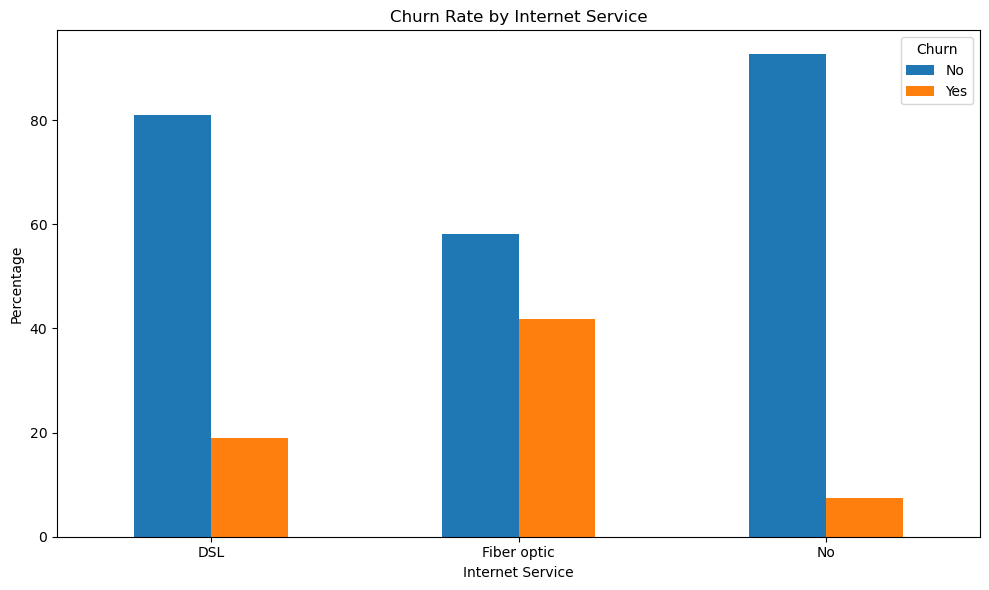

In [39]:
# Analyze churn rates across different internet service types
internet_churn = pd.crosstab(
    df_clean["InternetService"],
    df_clean["Churn"],
    normalize="index"
) * 100
print("Churn Percentage by Internet Service:")
print(internet_churn.round(2))
internet_churn.plot(
    kind="bar",
    figsize=(10, 6)
)
plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

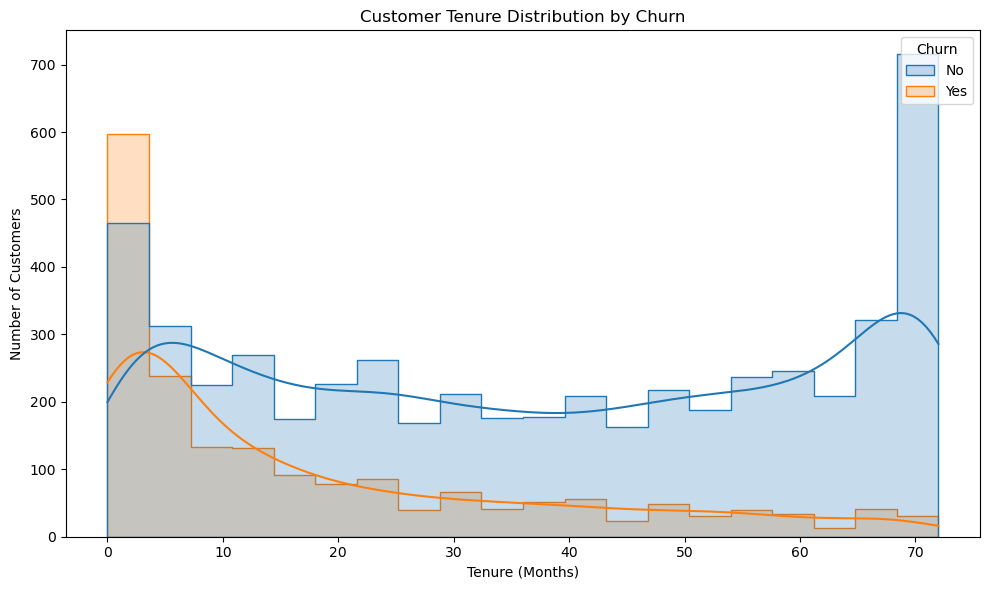

In [41]:
# Visualize the distribution of customer tenure for churned and retained customers
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_clean,
    x="tenure",
    hue="Churn",
    bins=20,
    kde=True,
    element="step"
)
plt.title("Customer Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

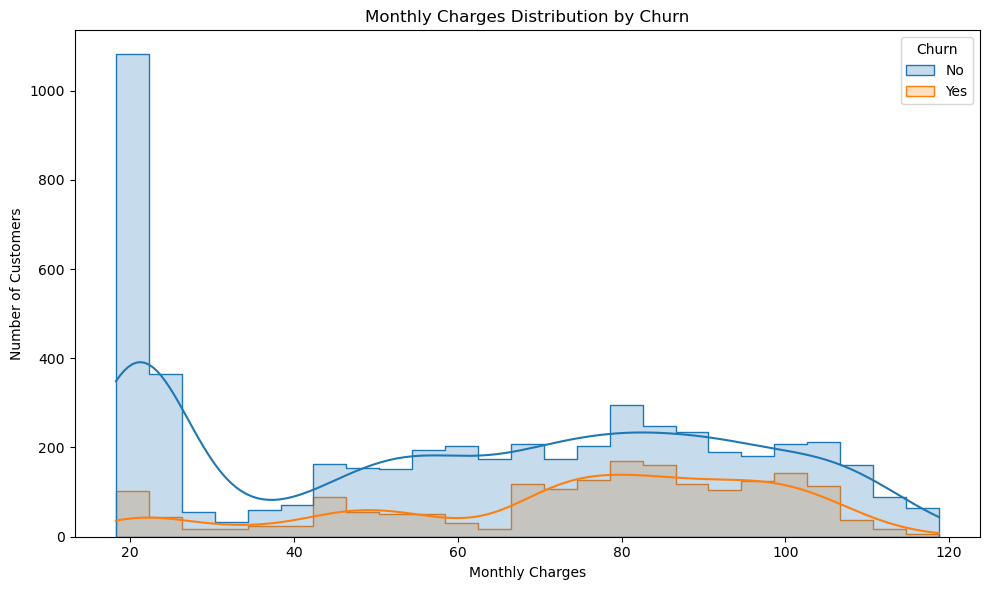

In [43]:
# Compare the distribution of monthly charges for churned and retained customers
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_clean,
    x="MonthlyCharges",
    hue="Churn",
    bins=25,
    kde=True,
    element="step"
)
plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [45]:
# Remove duplicate customer records from the cleaned dataset
before_duplicates = df_clean.shape[0]
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
after_duplicates = df_clean.shape[0]
print("Duplicate records removed:", before_duplicates - after_duplicates)
print("Dataset shape after removing duplicates:", df_clean.shape)

Duplicate records removed: 22
Dataset shape after removing duplicates: (7021, 20)


In [47]:
# Create a new feature representing the customer's average monthly spending
df_clean["AverageMonthlySpend"] = np.where(
    df_clean["tenure"] > 0,
    df_clean["TotalCharges"] / df_clean["tenure"],
    df_clean["MonthlyCharges"]
)
print("AverageMonthlySpend feature created successfully.")
print("\nSample values:")
print(
    df_clean[
        ["tenure", "MonthlyCharges", "TotalCharges", "AverageMonthlySpend"]
    ].head()
)

AverageMonthlySpend feature created successfully.

Sample values:
   tenure  MonthlyCharges  TotalCharges  AverageMonthlySpend
0       1           29.85         29.85            29.850000
1      34           56.95       1889.50            55.573529
2       2           53.85        108.15            54.075000
3      45           42.30       1840.75            40.905556
4       2           70.70        151.65            75.825000


In [49]:
# Group contract types into short-term and long-term categories
df_clean["ContractGroup"] = df_clean["Contract"].replace({
    "Month-to-month": "Short-Term",
    "One year": "Long-Term",
    "Two year": "Long-Term"
})
print("ContractGroup feature created successfully.")
print("\nContract Group Distribution:")
print(df_clean["ContractGroup"].value_counts())

ContractGroup feature created successfully.

Contract Group Distribution:
ContractGroup
Short-Term    3853
Long-Term     3168
Name: count, dtype: int64


In [51]:
# Verify the newly engineered features
print("Updated Dataset Shape:", df_clean.shape)
print("\nNew Features:")
print(
    df_clean[
        ["Contract", "ContractGroup",
         "tenure", "MonthlyCharges",
         "TotalCharges", "AverageMonthlySpend"]
    ].head()
)
# Display the final list of features before preprocessing
print("Final Columns:")
for column in df_clean.columns:
    print("-", column)
print("\nTotal Features Including Target:", len(df_clean.columns))

Updated Dataset Shape: (7021, 22)

New Features:
         Contract ContractGroup  tenure  MonthlyCharges  TotalCharges  \
0  Month-to-month    Short-Term       1           29.85         29.85   
1        One year     Long-Term      34           56.95       1889.50   
2  Month-to-month    Short-Term       2           53.85        108.15   
3        One year     Long-Term      45           42.30       1840.75   
4  Month-to-month    Short-Term       2           70.70        151.65   

   AverageMonthlySpend  
0            29.850000  
1            55.573529  
2            54.075000  
3            40.905556  
4            75.825000  
Final Columns:
- gender
- SeniorCitizen
- Partner
- Dependents
- tenure
- PhoneService
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
- Contract
- PaperlessBilling
- PaymentMethod
- MonthlyCharges
- TotalCharges
- Churn
- AverageMonthlySpend
- ContractGroup

Total Features Incl

In [53]:
# Separate input features from the target variable
X = df_clean.drop("Churn", axis=1)
y = df_clean["Churn"]
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget values:")
print(y.value_counts())

Features shape: (7021, 21)
Target shape: (7021,)

Target values:
Churn
No     5164
Yes    1857
Name: count, dtype: int64


In [55]:
# Convert the Churn target variable from Yes/No to 1/0
y = y.map({
    "No": 0,
    "Yes": 1
})
print("Encoded target values:")
print(y.value_counts())
print("\nTarget data type:", y.dtype)

Encoded target values:
Churn
0    5164
1    1857
Name: count, dtype: int64

Target data type: int64


In [57]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training data shape: (5616, 21)
Testing data shape: (1405, 21)

Training target distribution:
Churn
0    0.736
1    0.264
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


In [59]:
# Identify numerical and categorical features for preprocessing
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()
print("Numerical Features:")
print(numerical_features)
print("\nCategorical Features:")
print(categorical_features)
print("\nNumber of Numerical Features:", len(numerical_features))
print("Number of Categorical Features:", len(categorical_features))

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AverageMonthlySpend']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'ContractGroup']

Number of Numerical Features: 5
Number of Categorical Features: 16


In [61]:
# Create preprocessing pipelines for numerical and categorical features
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)
print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [63]:
# Apply the preprocessing pipeline to training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print("Training data after preprocessing:", X_train_processed.shape)
print("Testing data after preprocessing:", X_test_processed.shape)
print("\nPreprocessing completed successfully.")

Training data after preprocessing: (5616, 48)
Testing data after preprocessing: (1405, 48)

Preprocessing completed successfully.


In [65]:
# Verify the processed feature matrices
print("Processed Training Data Type:", type(X_train_processed))
print("Processed Testing Data Type:", type(X_test_processed))
print("\nProcessed Training Data Shape:", X_train_processed.shape)
print("Processed Testing Data Shape:", X_test_processed.shape)

Processed Training Data Type: <class 'numpy.ndarray'>
Processed Testing Data Type: <class 'numpy.ndarray'>

Processed Training Data Shape: (5616, 48)
Processed Testing Data Shape: (1405, 48)


In [67]:
# Import classification models for customer churn prediction
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
print("Classification models imported successfully.")

Classification models imported successfully.


In [69]:
# Create multiple classification models for comparison
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}
print("Models created successfully.")
for model_name in models:
    print("-", model_name)

Models created successfully.
- Logistic Regression
- Decision Tree
- Random Forest


In [73]:
# TOPIC 10 — MODEL BUILDING AND PREDICTIONS

# Import classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Create classification models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

print("Classification models created successfully.")
print()

# Train all models
trained_models = {}

for model_name, model in models.items():

    model.fit(X_train_processed, y_train)

    trained_models[model_name] = model

    print(f"{model_name} trained successfully.")

# Generate predictions
predictions = {}

for model_name, model in trained_models.items():

    predictions[model_name] = model.predict(X_test_processed)

    print(f"{model_name} predictions generated successfully.")
    
# Generate churn probabilities
probabilities = {}

for model_name, model in trained_models.items():

    probabilities[model_name] = model.predict_proba(
        X_test_processed
    )[:, 1]

    print(f"{model_name} probabilities generated successfully.")

print()
print("TOPIC 10 completed successfully.")

Classification models created successfully.

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
Logistic Regression predictions generated successfully.
Decision Tree predictions generated successfully.
Random Forest predictions generated successfully.
Logistic Regression probabilities generated successfully.
Decision Tree probabilities generated successfully.
Random Forest probabilities generated successfully.

TOPIC 10 completed successfully.


In [75]:
# TOPIC 11 — MODEL EVALUATION

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Calculate evaluation metrics for all models
model_results = []
for model_name, y_pred in predictions.items():
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

# Create results DataFrame
results_df = pd.DataFrame(model_results)

# Rank models by F1 Score
results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

print("MODEL EVALUATION RESULTS")
print("=" * 60)

display(results_df.round(4))

# Identify the best-performing model
best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]
best_predictions = predictions[best_model_name]
print()
print("BEST MODEL")
print("=" * 60)
print("Model:", best_model_name)
print("Accuracy:", round(results_df.loc[0, "Accuracy"], 4))
print("Precision:", round(results_df.loc[0, "Precision"], 4))
print("Recall:", round(results_df.loc[0, "Recall"], 4))
print("F1 Score:", round(results_df.loc[0, "F1 Score"], 4))

# Classification report for the best model
print()
print("CLASSIFICATION REPORT")
print("=" * 60)
print(
    classification_report(
        y_test,
        best_predictions,
        target_names=["Stayed", "Churned"]
    )
)

# Confusion matrix values
cm = confusion_matrix(
    y_test,
    best_predictions
)

print("CONFUSION MATRIX")
print("=" * 60)
print(cm)
print()
print("TOPIC 11 completed successfully.")

MODEL EVALUATION RESULTS


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8028,0.6610,0.5242,0.5847
1,Random Forest,0.7808,0.6151,0.4597,0.5262
2,Decision Tree,0.7203,0.4731,0.4973,0.4849



BEST MODEL
Model: Logistic Regression
Accuracy: 0.8028
Precision: 0.661
Recall: 0.5242
F1 Score: 0.5847

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Stayed       0.84      0.90      0.87      1033
     Churned       0.66      0.52      0.58       372

    accuracy                           0.80      1405
   macro avg       0.75      0.71      0.73      1405
weighted avg       0.79      0.80      0.80      1405

CONFUSION MATRIX
[[933 100]
 [177 195]]

TOPIC 11 completed successfully.


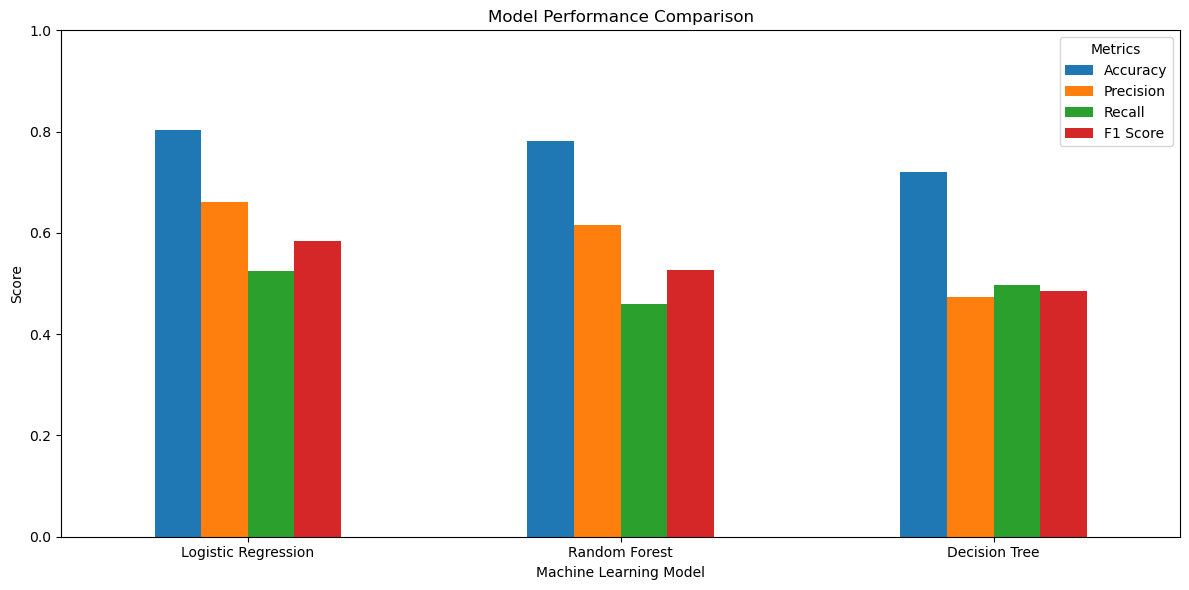

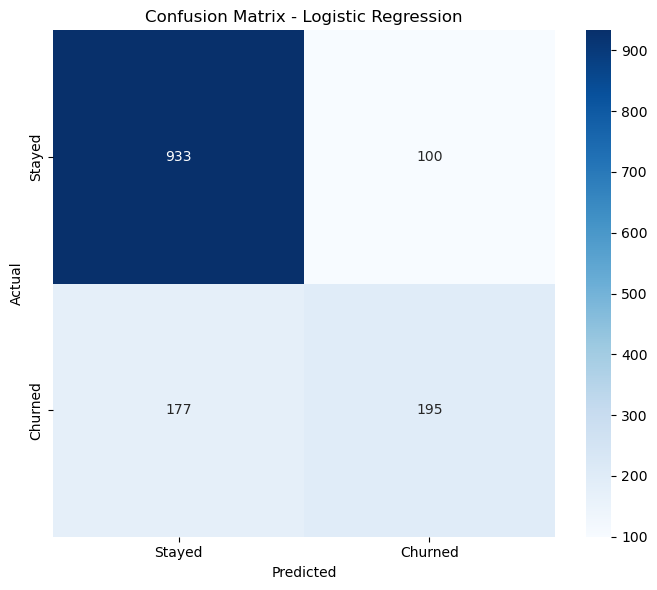

TOP 10 IMPORTANT FEATURES


,Feature,Coefficient,Absolute_Coefficient
1,tenure,-1.3867,1.3867
3,TotalCharges,0.6485,0.6485
39,Contract_Two year,-0.5622,0.5622
16,InternetService_DSL,-0.5526,0.5526
17,InternetService_Fiber optic,0.5344,0.5344
46,ContractGroup_Long-Term,-0.4346,0.4346
40,PaperlessBilling_No,-0.2955,0.2955
13,MultipleLines_No,-0.2866,0.2866
2,MonthlyCharges,-0.2814,0.2814
23,OnlineBackup_No internet service,-0.2333,0.2333


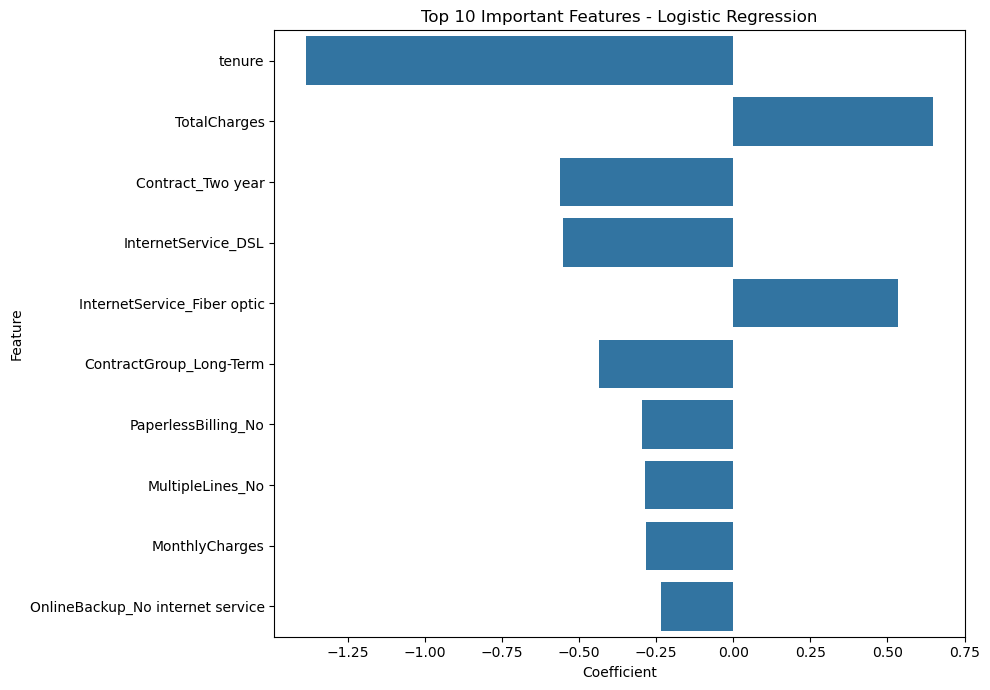


TOPIC 12 completed successfully.


In [81]:
# TOPIC 12 — MODEL PERFORMANCE VISUALIZATION

# 1. Compare Accuracy, Precision, Recall and F1 Score
metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]
results_plot = results_df.set_index("Model")[metrics_to_plot]
results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)
plt.title("Model Performance Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

# 2. Confusion Matrix for the Best Model
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 3. Get feature names from the preprocessing pipeline
feature_names = preprocessor.get_feature_names_out()

# Clean the feature names for easier reading
feature_names = [
    name.replace("num__", "")
         .replace("cat__", "")
         .replace("onehot__", "")
    for name in feature_names
]

# 4. Feature Importance / Coefficients
if best_model_name == "Logistic Regression":
    coefficients = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": best_model.coef_[0]
    })
    coefficients["Absolute_Coefficient"] = (
        coefficients["Coefficient"].abs()
    )
    coefficients = coefficients.sort_values(
        by="Absolute_Coefficient",
        ascending=False
    )
    print("TOP 10 IMPORTANT FEATURES")
    print("=" * 50)
    display(
        coefficients.head(10).round(4)
    )
    plt.figure(figsize=(10, 7))
    sns.barplot(
        data=coefficients.head(10),
        x="Coefficient",
        y="Feature"
    )
    plt.title("Top 10 Important Features - Logistic Regression")
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": best_model.feature_importances_
    })
    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )
    print("TOP 10 IMPORTANT FEATURES")
    print("=" * 50)
    display(
        feature_importance.head(10).round(4)
    )

    plt.figure(figsize=(10, 7))

    sns.barplot(
        data=feature_importance.head(10),
        x="Importance",
        y="Feature"
    )

    plt.title(
        f"Top 10 Important Features - {best_model_name}"
    )

    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()


print()
print("TOPIC 12 completed successfully.")

In [87]:

# TOPIC 13 — FINAL CUSTOMER CHURN PREDICTION SYSTEM

# Create a function to predict churn for a new customer
def predict_customer_churn(customer_data):
    # Convert customer information into a DataFrame
    customer_df = pd.DataFrame([customer_data])
    # Create the same engineered features used during training

    # Calculate average monthly spending
    if customer_df["tenure"].iloc[0] > 0:
        customer_df["AverageMonthlySpend"] = (
            customer_df["TotalCharges"] /
            customer_df["tenure"]
        )
    else:
        customer_df["AverageMonthlySpend"] = (
            customer_df["MonthlyCharges"]
        )
    # Group contract types
    customer_df["ContractGroup"] = customer_df["Contract"].map({
        "Month-to-month": "Short Term",
        "One year": "Long Term",
        "Two year": "Long Term"
    })

    # Apply the same preprocessing used during training
    customer_processed = preprocessor.transform(customer_df)
    
    # Predict churn
    prediction = best_model.predict(
        customer_processed
    )[0]

    churn_probability = best_model.predict_proba(
        customer_processed
    )[0][1]
    
    # Convert prediction into readable output
    if prediction == 1:
        churn_status = "Likely to Churn"
    else:
        churn_status = "Likely to Stay"

    return churn_status, churn_probability

# Example new customer
new_customer = {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 5,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 85.50,
    "TotalCharges": 427.50
}

# Generate churn prediction
churn_status, churn_probability = predict_customer_churn(
    new_customer
)

# Determine customer risk level
if churn_probability >= 0.70:
    risk_level = "High Risk"
elif churn_probability >= 0.40:
    risk_level = "Medium Risk"
else:
    risk_level = "Low Risk"

# Display clean final result
print("CUSTOMER CHURN PREDICTION")
print("=" * 45)
print(f"Prediction        : {churn_status}")
print(f"Churn Probability : {churn_probability * 100:.2f}%")
print(f"Risk Level        : {risk_level}")

print()
print("TOPIC 13 completed successfully.")

CUSTOMER CHURN PREDICTION
Prediction        : Likely to Churn
Churn Probability : 71.95%
Risk Level        : High Risk

TOPIC 13 completed successfully.


In [91]:
#SAVE AND VERIFY FINAL CHURN PREDICTION SYSTEM

import joblib
# Save the trained model
joblib.dump(best_model, "customer_churn_model.pkl")

# Save the preprocessing pipeline
joblib.dump(preprocessor, "customer_churn_preprocessor.pkl")

# Verify that both files can be loaded
loaded_model = joblib.load("customer_churn_model.pkl")
loaded_preprocessor = joblib.load("customer_churn_preprocessor.pkl")
print("FINAL MODEL SAVING & VERIFICATION")
print("=" * 45)
print("Model saved successfully.")
print("Preprocessor saved successfully.")
print("Model loaded successfully.")
print("Preprocessor loaded successfully.")
print()
print("Selected Model:", best_model_name)
print("Project Status: COMPLETED")
print("=" * 45)
print("TOPIC 14 completed successfully.")

FINAL MODEL SAVING & VERIFICATION
Model saved successfully.
Preprocessor saved successfully.
Model loaded successfully.
Preprocessor loaded successfully.

Selected Model: Logistic Regression
Project Status: COMPLETED
TOPIC 14 completed successfully.


In [95]:

# TOPIC 15 — FINAL PROJECT SUMMARY

# Get the results of the selected model from the evaluation table
best_results = results_df[results_df["Model"] == best_model_name].iloc[0]
print("CUSTOMER CHURN PREDICTION SYSTEM")
print("=" * 55)
print("Dataset: Telco Customer Churn")
print("Total Customers:", len(df))
print("Target Variable: Churn")
print()
print("MODELS TESTED")
print("-" * 55)
print("1. Logistic Regression")
print("2. Random Forest")
print("3. Decision Tree")
print()
print("BEST MODEL")
print("-" * 55)
print("Model:", best_model_name)
print("Accuracy:", round(best_results["Accuracy"], 4))
print("Precision:", round(best_results["Precision"], 4))
print("Recall:", round(best_results["Recall"], 4))
print("F1 Score:", round(best_results["F1 Score"], 4))
print()
print("PROJECT COMPONENTS COMPLETED")
print("-" * 55)
print("Done Data Collection")
print("Done Data Preprocessing")
print("Done Exploratory Data Analysis")
print("Done Feature Engineering")
print("Done Classification Models")
print("Done Model Evaluation")
print("Done Churn Prediction")
print("Done Model Saving & Verification")
print()
print("=" * 55)
print("TASK 4 — CUSTOMER CHURN PREDICTION COMPLETED")
print("=" * 55)
print("TOPIC 15 completed successfully.")

CUSTOMER CHURN PREDICTION SYSTEM
Dataset: Telco Customer Churn
Total Customers: 7043
Target Variable: Churn

MODELS TESTED
-------------------------------------------------------
1. Logistic Regression
2. Random Forest
3. Decision Tree

BEST MODEL
-------------------------------------------------------
Model: Logistic Regression
Accuracy: 0.8028
Precision: 0.661
Recall: 0.5242
F1 Score: 0.5847

PROJECT COMPONENTS COMPLETED
-------------------------------------------------------
Done Data Collection
Done Data Preprocessing
Done Exploratory Data Analysis
Done Feature Engineering
Done Classification Models
Done Model Evaluation
Done Churn Prediction
Done Model Saving & Verification

TASK 4 — CUSTOMER CHURN PREDICTION COMPLETED
TOPIC 15 completed successfully.
